In [1]:
## EDA and Feature Engineering - Data Cleaning Done
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("data/google_cleaned.csv",index_col=0)
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
 13  Day             10840 non-null  int64  
 14  Month           10840 non-null  int64  
 15  Year            10840 non-null  int64  
dtypes: float64(3), int64(5), str(8)
memory usage: 1.4 MB


In [4]:
df[df.duplicated("App")].shape

(1181, 16)

In [5]:
## Observation : Dataset has duplicate records
## Drop all the duplicates

In [6]:
df=df.drop_duplicates(subset=["App"],keep="first") 

In [7]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [8]:
df.shape

(9659, 16)

In [9]:
## Explore Data More
df.info()

<class 'pandas.DataFrame'>
Index: 9659 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   str    
 1   Category        9659 non-null   str    
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            8432 non-null   float64
 5   Installs        9659 non-null   int64  
 6   Type            9658 non-null   str    
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   str    
 9   Genres          9659 non-null   str    
 10  Last Updated    9659 non-null   str    
 11  Current Ver     9651 non-null   str    
 12  Android Ver     9657 non-null   str    
 13  Day             9659 non-null   int64  
 14  Month           9659 non-null   int64  
 15  Year            9659 non-null   int64  
dtypes: float64(3), int64(5), str(8)
memory usage: 1.3 MB


In [10]:
numerical_columns=[feature for feature in df.columns if df[feature].dtype != "string"]
categorical_columns=[feature for feature in df.columns if df[feature].dtype == "string"]

print(f"We have {len(numerical_columns)} numerical columns : {numerical_columns}")
print(f"We have {len(categorical_columns)} categorical columns : {categorical_columns}")

We have 8 numerical columns : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Day', 'Month', 'Year']
We have 8 categorical columns : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [11]:
df["App"].dtype

<StringDtype(storage='python', na_value=nan)>

In [12]:
df["Last Updated"]=pd.to_datetime(df["Last Updated"])

In [13]:
numerical_columns=[feature for feature in df.columns if df[feature].dtype != "string"]
categorical_columns=[feature for feature in df.columns if df[feature].dtype == "string"]

print(f"We have {len(numerical_columns)} numerical columns : {numerical_columns}")
print(f"We have {len(categorical_columns)} categorical columns : {categorical_columns}")

We have 9 numerical columns : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day', 'Month', 'Year']
We have 7 categorical columns : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


In [14]:
# figure=plt.figure(figsize=(10,10))
# sns.barplot(df["App"].value_counts(normalize=True)*100)
# plt.show()

Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PRODUCTIVITY            3.872036
LIFESTYLE               3.820271
FINANCE                 3.571798
SPORTS                  3.364738
COMMUNICATION           3.261207
HEALTH_AND_FITNESS      2.981675
PHOTOGRAPHY             2.909204
NEWS_AND_MAGAZINES      2.629672
SOCIAL                  2.474376
BOOKS_AND_REFERENCE     2.298375
TRAVEL_AND_LOCAL        2.267315
SHOPPING                2.091314
DATING                  1.770370
VIDEO_PLAYERS           1.687545
MAPS_AND_NAVIGATION     1.356248
EDUCATION               1.232012
FOOD_AND_DRINK          1.159540
ENTERTAINMENT           1.056010
AUTO_AND_VEHICLES       0.880008
LIBRARIES_AND_DEMO      0.869655
WEATHER                 0.817890
HOUSE_AND_HOME          0.766125
ART_AND_DESIGN          0.662594
EVENTS                  0.662594
P

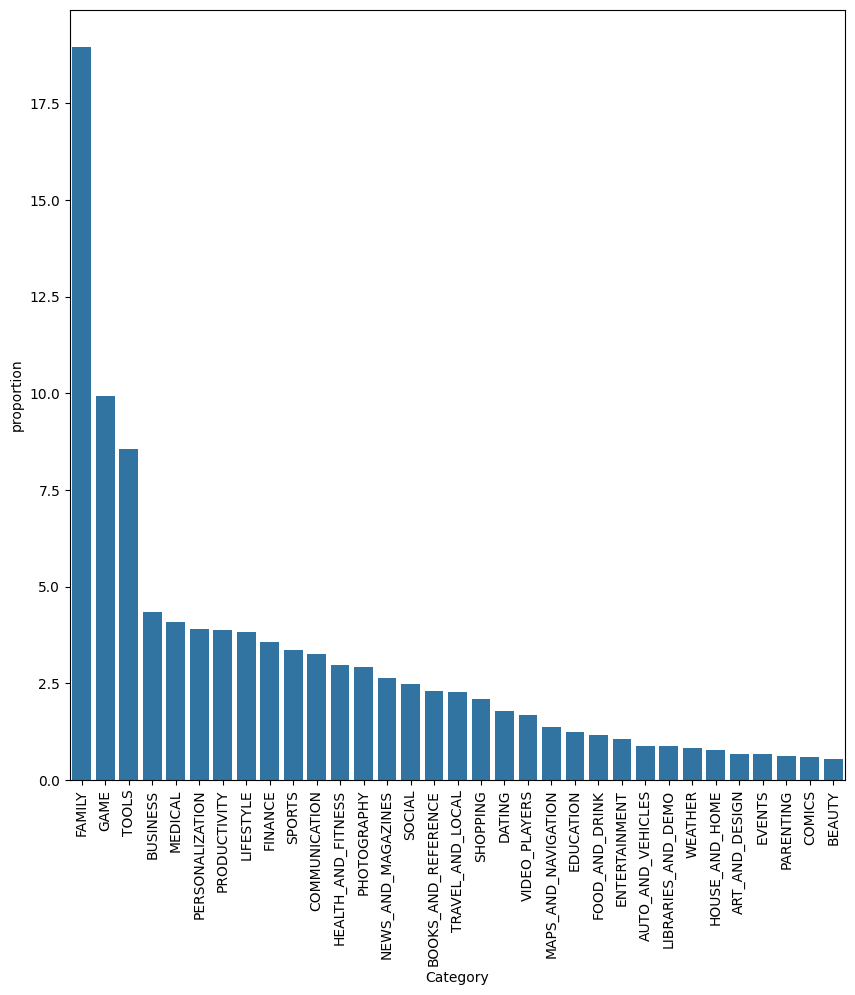

----------------------------------
Type
Free    92.172292
Paid     7.827708
Name: proportion, dtype: float64


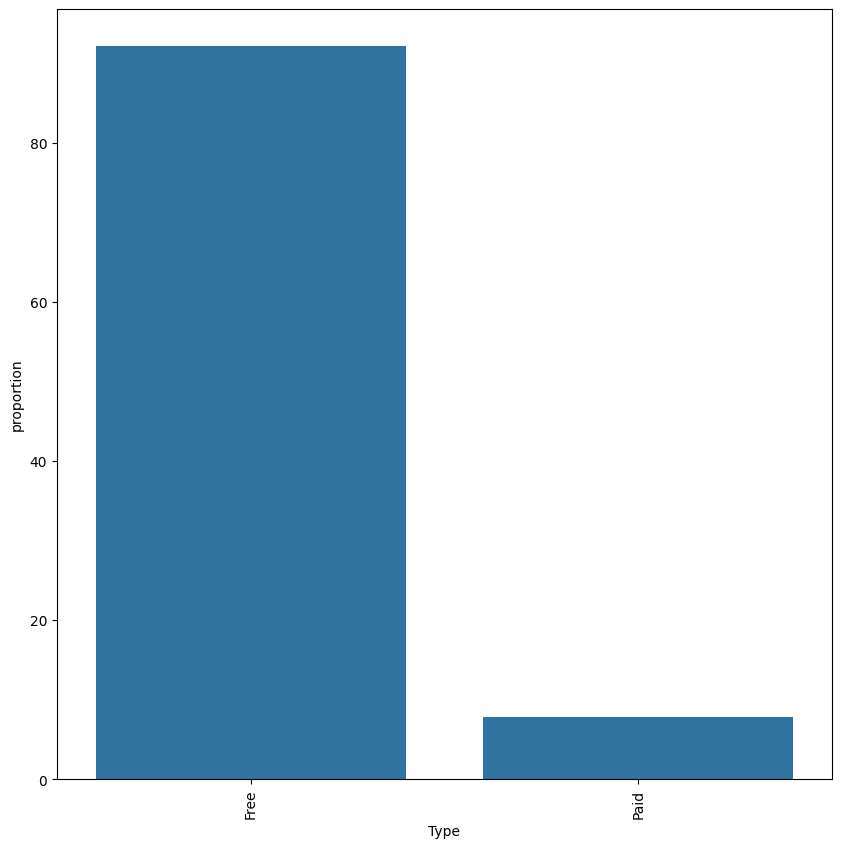

----------------------------------
Content Rating
Everyone           81.820064
Teen               10.725748
Mature 17+          4.068744
Everyone 10+        3.333678
Adults only 18+     0.031059
Unrated             0.020706
Name: proportion, dtype: float64


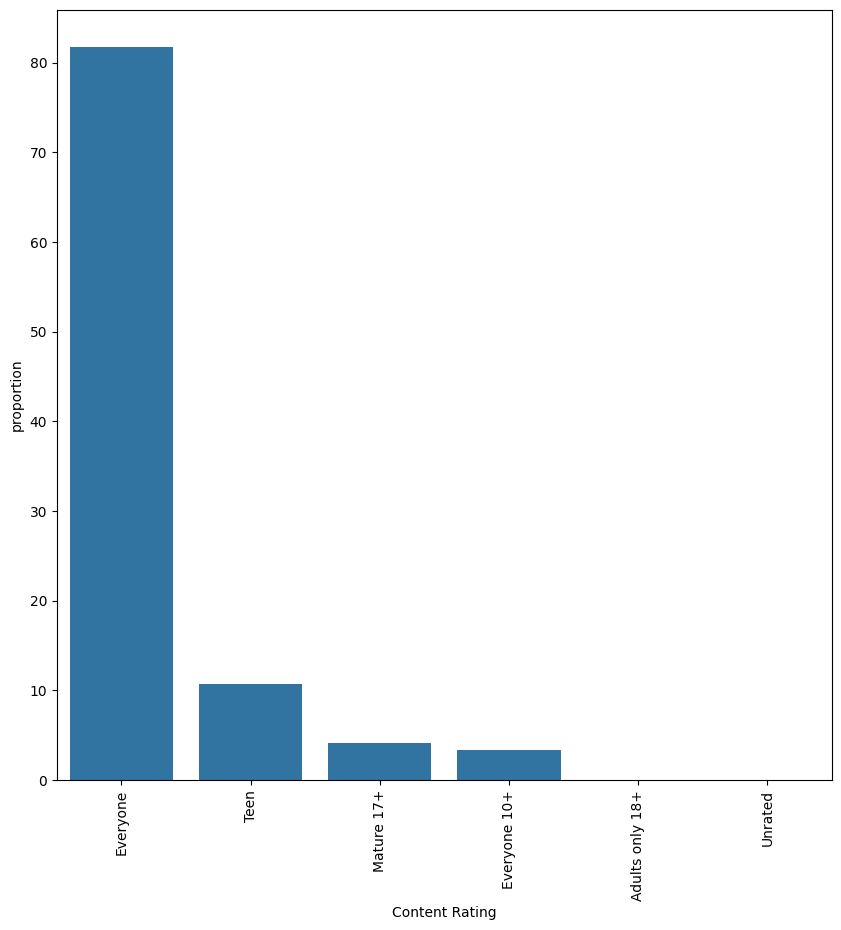

----------------------------------
Genres
Tools                       8.551610
Entertainment               5.808055
Education                   5.280050
Business                    4.348276
Medical                     4.089450
                              ...   
Role Playing;Brain Games    0.010353
Strategy;Education          0.010353
Racing;Pretend Play         0.010353
Communication;Creativity    0.010353
Strategy;Creativity         0.010353
Name: proportion, Length: 118, dtype: float64


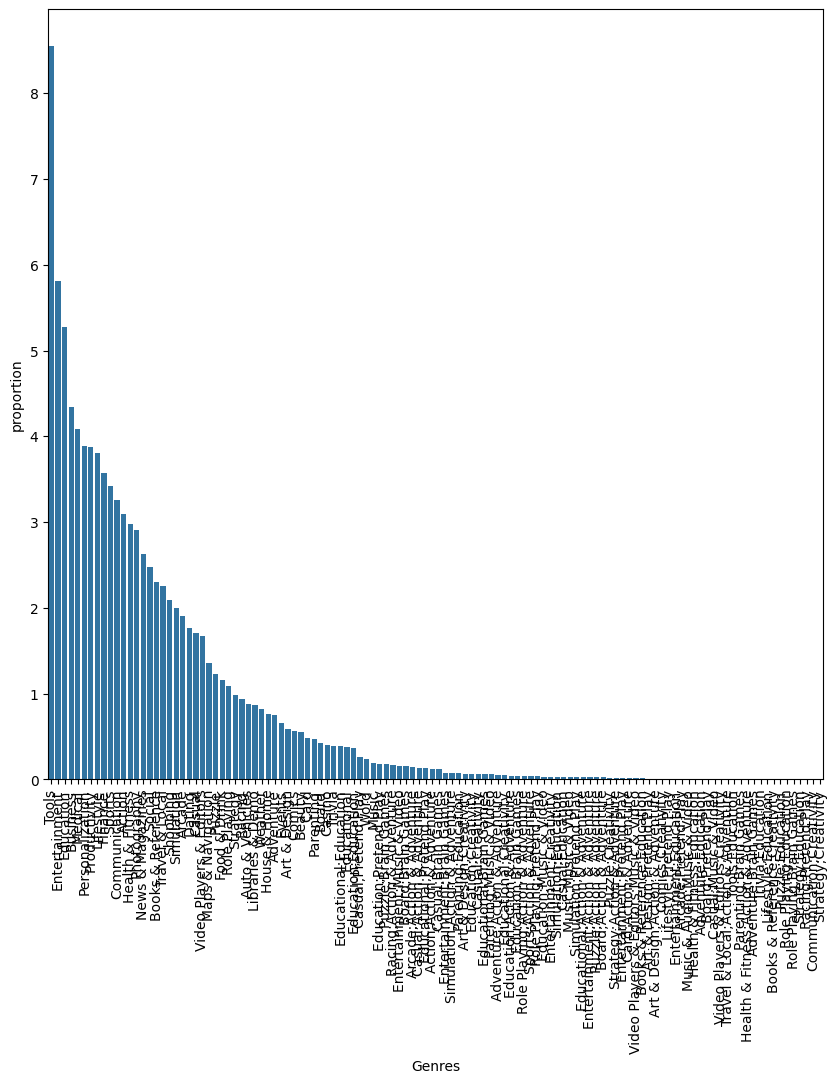

----------------------------------


In [18]:
## Proportion for count data on categorical columns
for col in categorical_columns[1:5]:
    stats=df[col].value_counts(normalize=True)*100
    print(stats)
    figure=plt.figure(figsize=(10,10))
    sns.barplot(df[col].value_counts(normalize=True)*100)
    plt.xticks(rotation=90)
    plt.show()
    print("----------------------------------")

In [21]:
len(numerical_columns),numerical_columns

(9,
 ['Rating',
  'Reviews',
  'Size',
  'Installs',
  'Price',
  'Last Updated',
  'Day',
  'Month',
  'Year'])

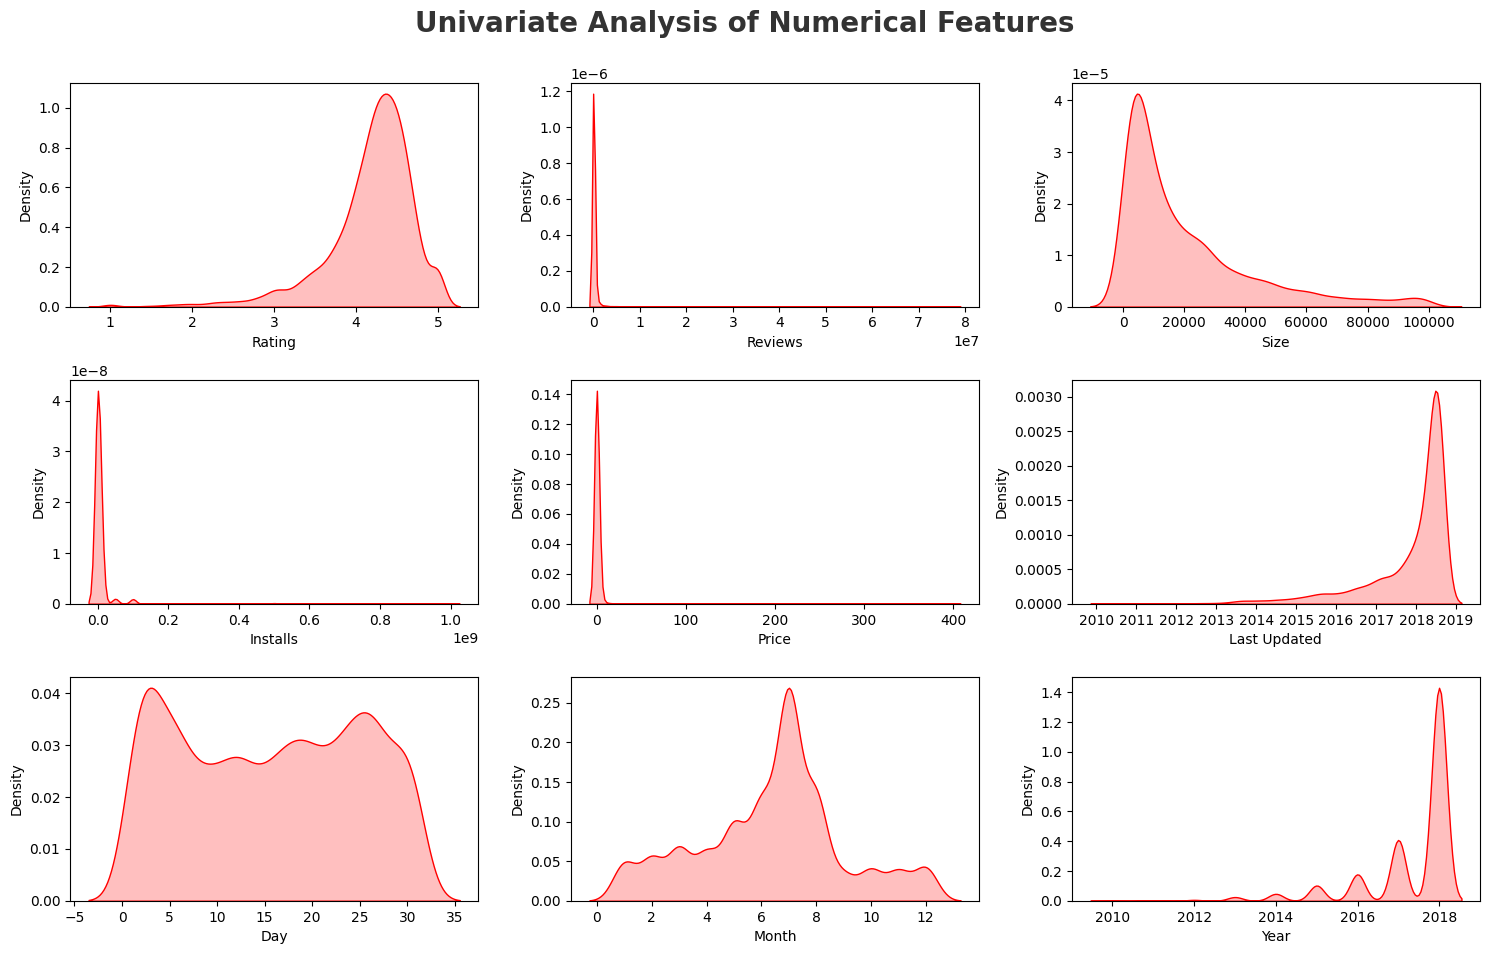

In [26]:
## Proportion of count data on categorical columns
plt.figure(figsize=(15,15))
plt.suptitle("Univariate Analysis of Numerical Features", fontsize=20, fontweight="bold", alpha=0.8, y=1)

for i in range(0,len(numerical_columns)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df[numerical_columns[i]],shade=True,color="r")
    plt.xlabel(numerical_columns[i])
    plt.tight_layout()


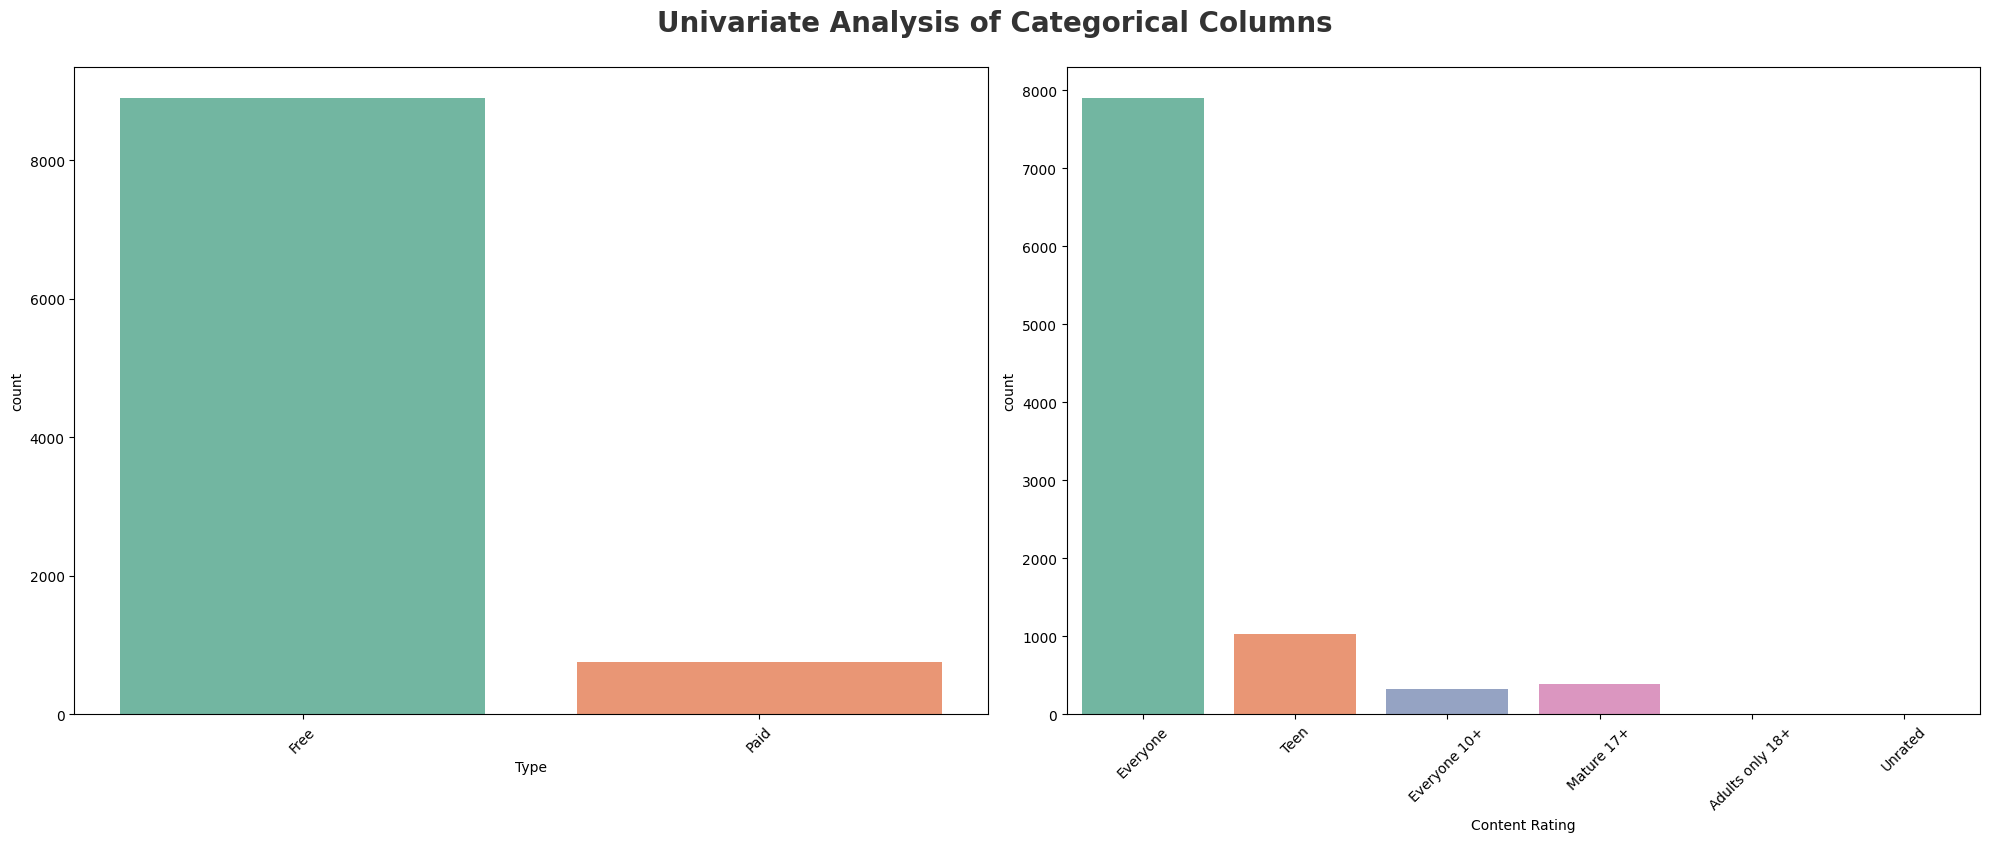

In [32]:
# Rating, Year, Last Updated all are left skewed
# Reviews, Size, Installs and Price are right skewed

plt.figure(figsize=(20,15))
plt.suptitle("Univariate Analysis of Categorical Columns", fontsize=20, fontweight="bold", alpha=0.8, y=1)
category=["Type","Content Rating"]
for i in range(0,len(category)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

In [33]:
# Most of the Apps are Free and designed for Everyone

In [34]:
## Which is the most popular app category??

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [39]:
df["Category"].value_counts()

Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           163
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
ART_AND_DESIGN           64
EVENTS                   64
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64

<Axes: >

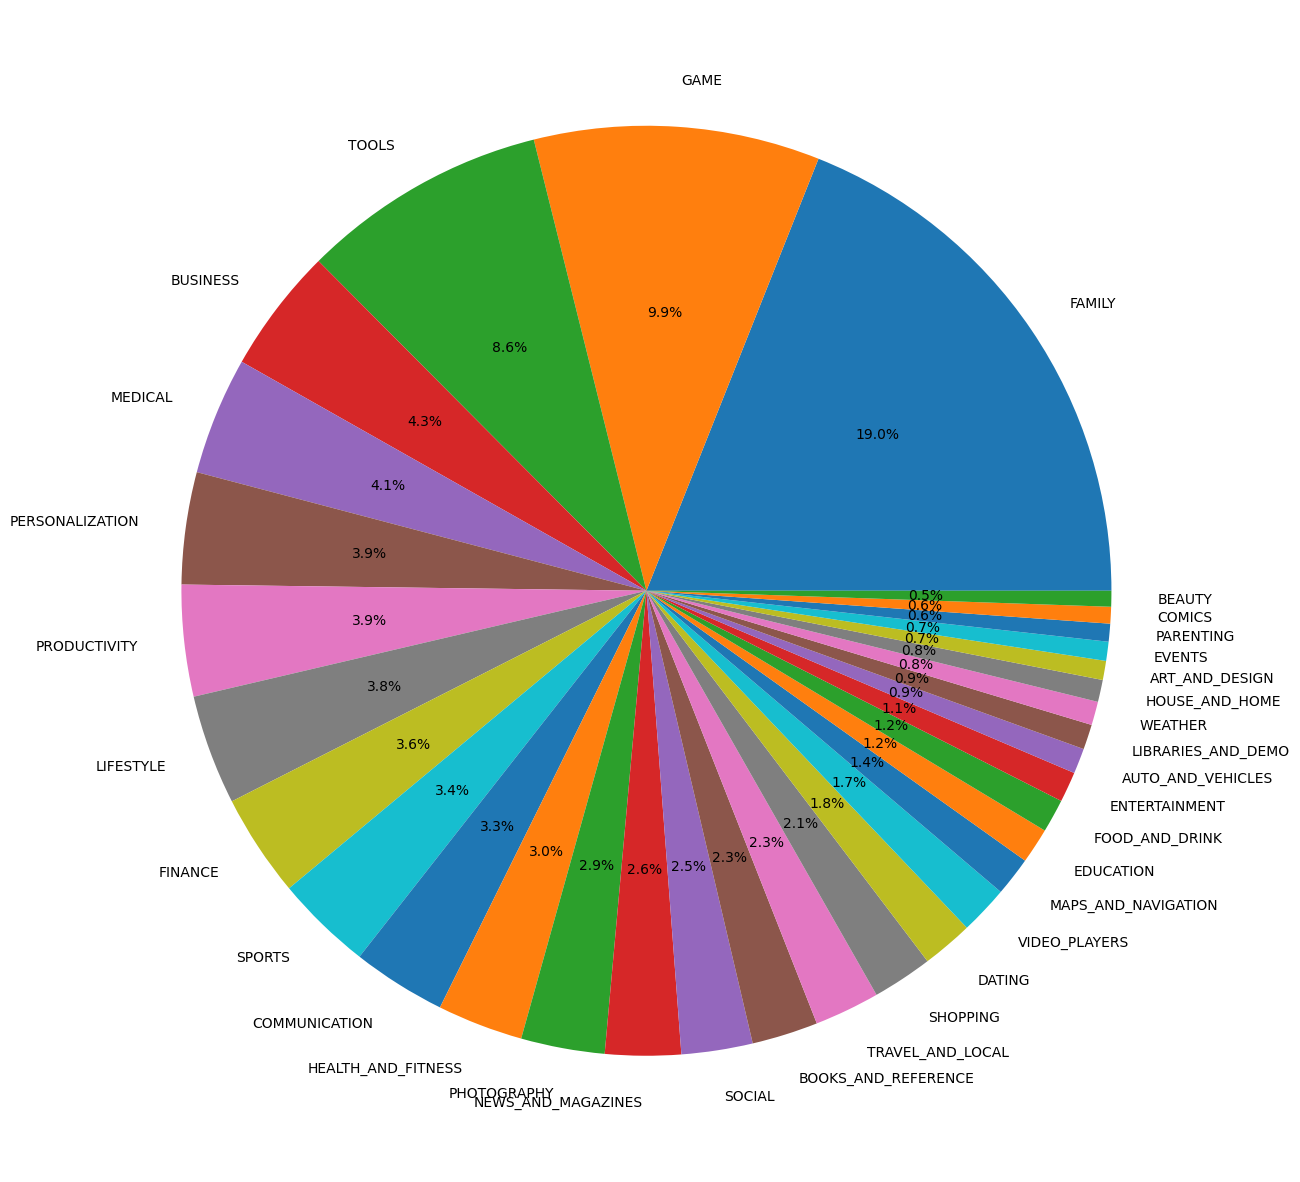

In [38]:
df["Category"].value_counts().plot.pie(df["Category"],figsize=(15,16),autopct="%1.1f%%")

In [40]:
## Observation
## There are more kinds of apps in playstore with categories -- Family, Games and Tools
## Beauty, Comics, Parenting, events and art and design categories are very less in playstore

In [57]:
### Top 10 App Categories
category=pd.DataFrame(df["Category"].value_counts())
category.rename(columns={"Category":"Count"},inplace=True)

In [58]:
category

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


In [70]:
category.iloc[:10].index

Index(['FAMILY', 'GAME', 'TOOLS', 'BUSINESS', 'MEDICAL', 'PERSONALIZATION',
       'PRODUCTIVITY', 'LIFESTYLE', 'FINANCE', 'SPORTS'],
      dtype='str', name='Category')

In [71]:
category.iloc[:10].values

array([[1832],
       [ 959],
       [ 827],
       [ 420],
       [ 395],
       [ 376],
       [ 374],
       [ 369],
       [ 345],
       [ 325]])

In [75]:
category[:10]

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


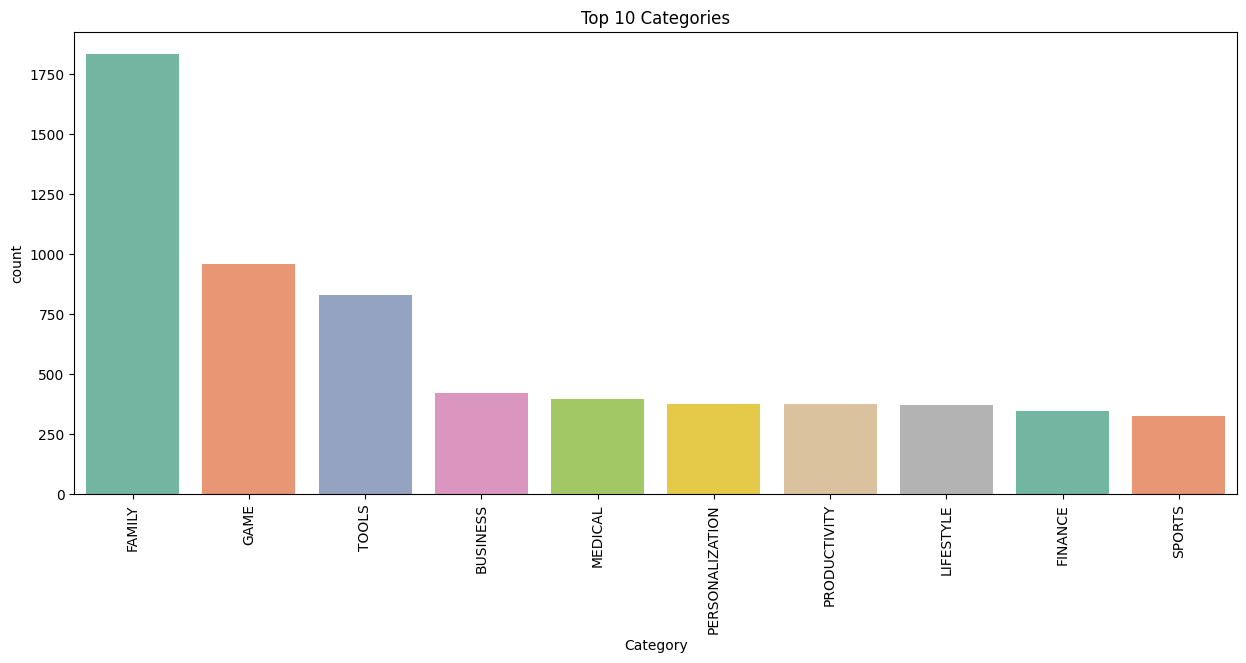

In [77]:
plt.figure(figsize=(15,6))
sns.barplot(x=category.iloc[:10].index,y="count",data=category[:10],palette="Set2")
plt.title("Top 10 Categories")
plt.xticks(rotation=90)
plt.show()

In [78]:
### Internal Assignments

## Which Category has largest number of installations??
## Which are the Top 5 most installed Apps in Each popular Categories??
## How many apps are there on Google Play Store which get 5 ratings??

df.head()    

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [88]:
grouped_by_category=df.groupby("Category")["Installs"].sum()

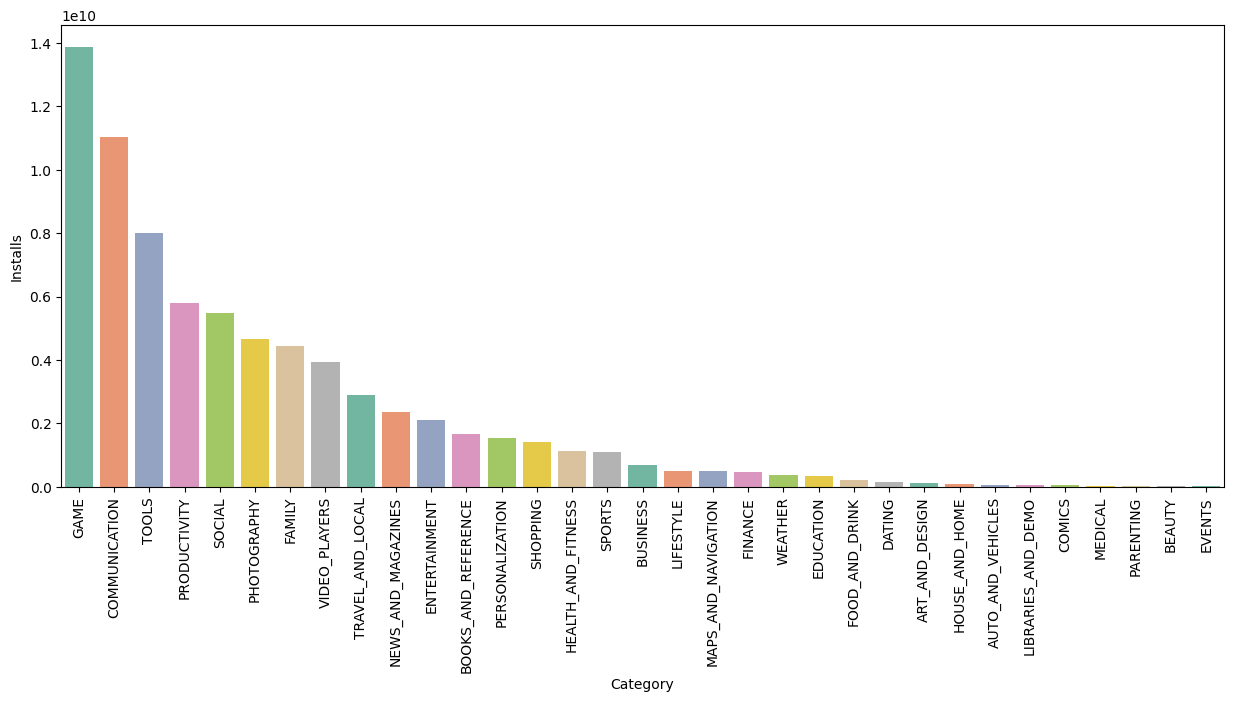

In [92]:
plt.figure(figsize=(15,6))
grouped_by_category=grouped_by_category.sort_values(ascending=False)
sns.barplot(grouped_by_category,palette="Set2")
plt.xticks(rotation=90)
plt.show()

In [91]:
# From the above graph -- we can see that game category had the most installations (in total)
# Where as in mean -- we have communication installation more.
# Which means that gaming there are few with high values(hence increasing the count)
# but communication all apps have consistent high number of installations

In [93]:
## Which are the Top 5 most installed Apps in Each popular Categories??
# Popular Category means --- which has most number of installations -- > 
# Lets take 10 Popular Categories and check the 5 most installed apps in each


top_categories=grouped_by_category[:10]

In [94]:
top_categories

Category
GAME                  13878924415
COMMUNICATION         11038276251
TOOLS                  8001771915
PRODUCTIVITY           5793091369
SOCIAL                 5487867902
PHOTOGRAPHY            4649147655
FAMILY                 4427941505
VIDEO_PLAYERS          3926902720
TRAVEL_AND_LOCAL       2894887146
NEWS_AND_MAGAZINES     2369217760
Name: Installs, dtype: int64

In [95]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


----------GAME----------
['Subway Surfers', 'Pou', 'My Talking Tom', 'Temple Run 2', 'Candy Crush Saga']
-------------------------
----------COMMUNICATION----------
['WhatsApp Messenger', 'Gmail', 'Google Chrome: Fast & Secure', 'Skype - free IM & video calls', 'Messenger – Text and Video Chat for Free']
-------------------------
----------TOOLS----------
['Google', 'Clean Master- Space Cleaner & Antivirus', 'Security Master - Antivirus, VPN, AppLock, Booster', 'Google Translate', 'Gboard - the Google Keyboard']
-------------------------
----------PRODUCTIVITY----------
['Google Drive', 'Microsoft Word', 'Dropbox', 'Google Calendar', 'Cloud Print']
-------------------------
----------SOCIAL----------
['Facebook', 'Google+', 'Instagram', 'Snapchat', 'Facebook Lite']
-------------------------
----------PHOTOGRAPHY----------
['Google Photos', 'Sweet Selfie - selfie camera, beauty cam, photo edit', 'BeautyPlus - Easy Photo Editor & Selfie Camera', 'S Photo Editor - Collage Maker , Photo Co

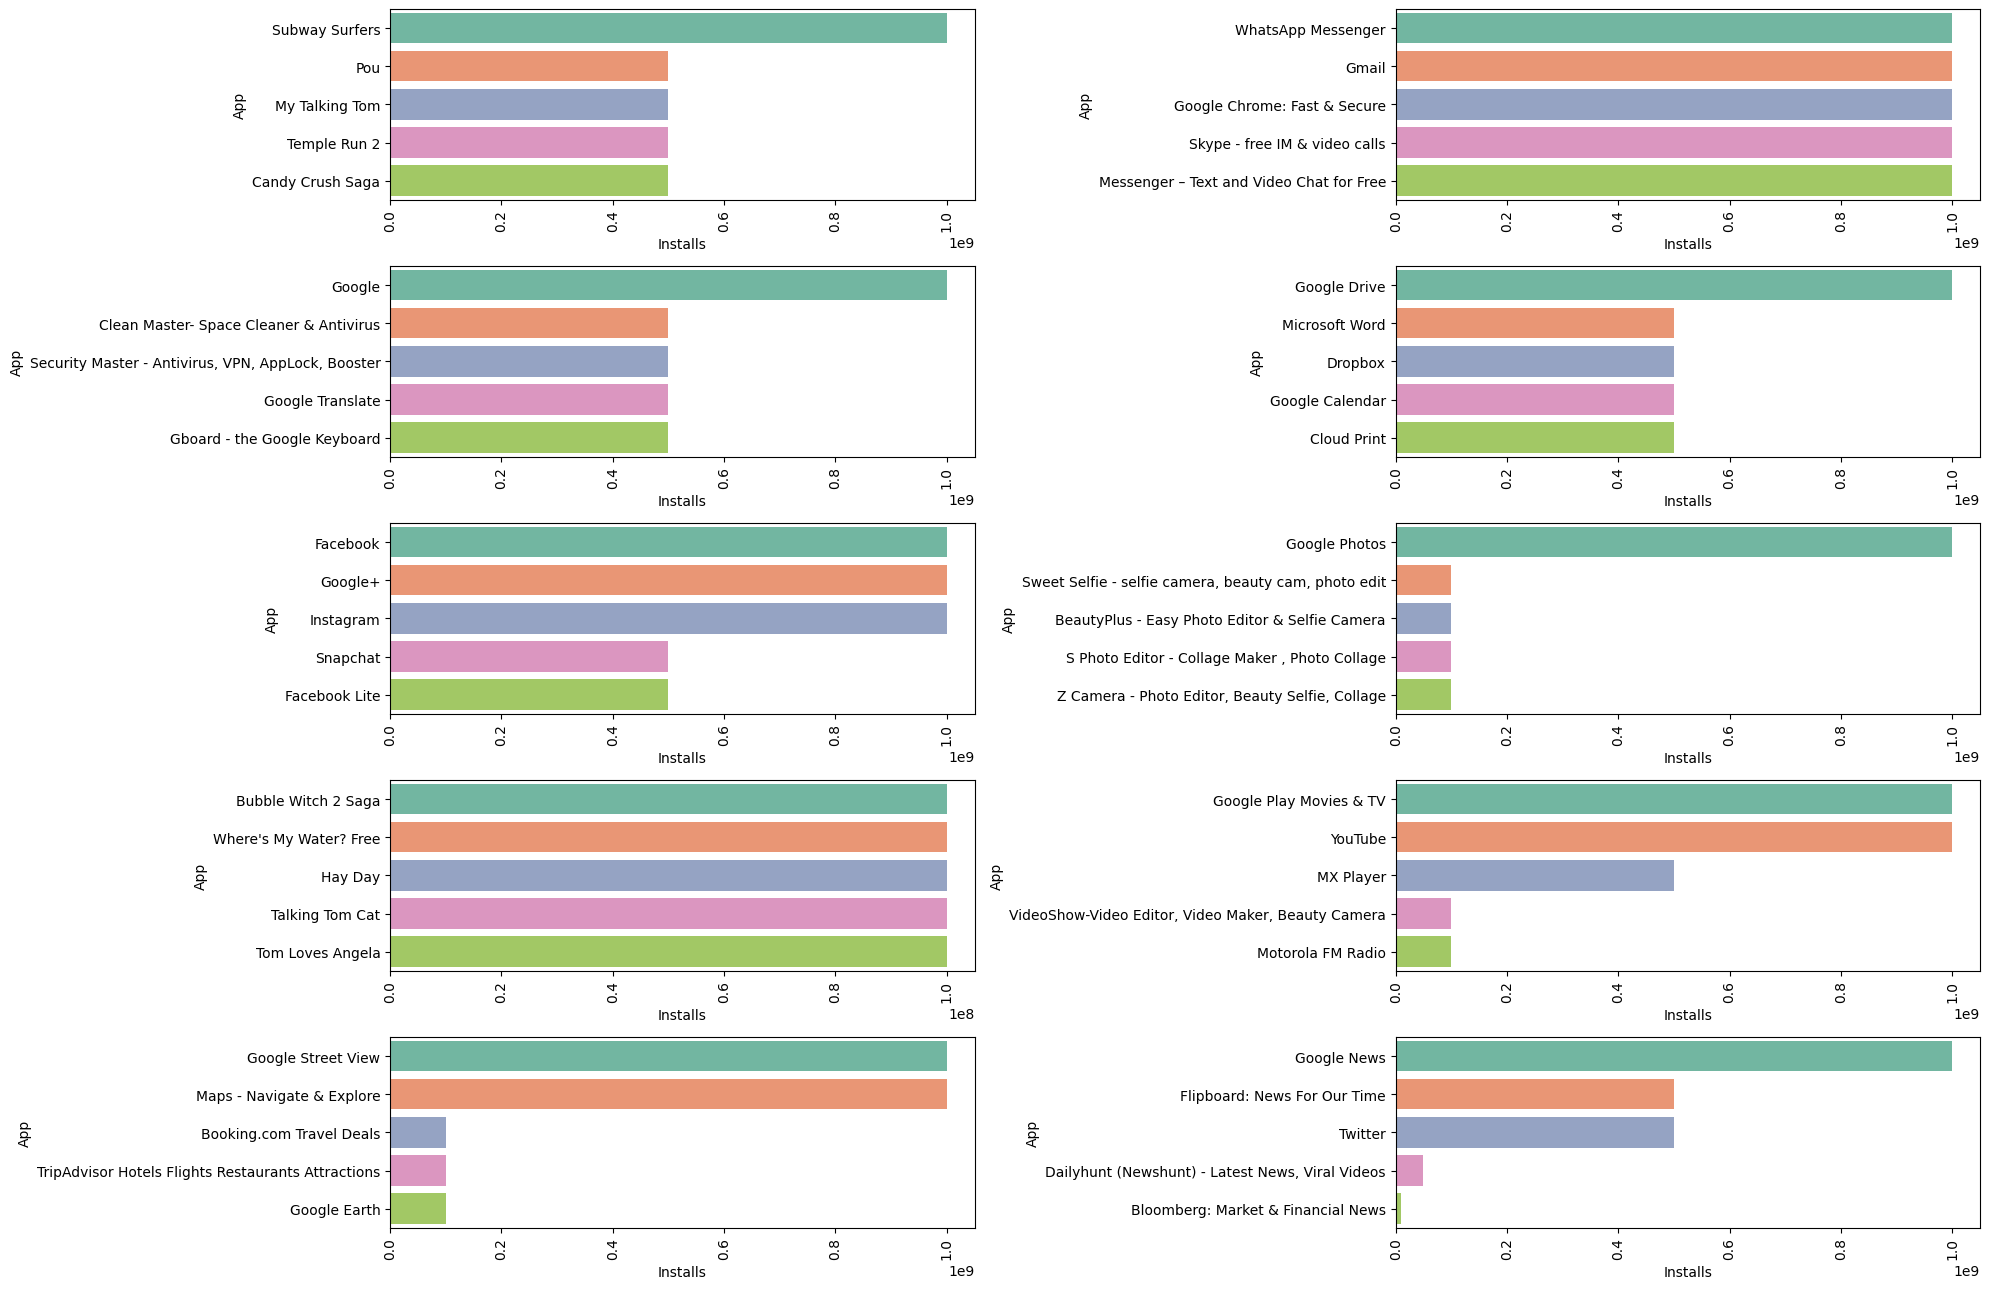

In [171]:
i=0
plt.figure(figsize=(20,13))
for category in top_categories.index:
    i=i+1
    category_df=df[df["Category"]==category]
    app_grouped_by_installation=category_df.groupby("App")["Installs"].sum().sort_values(ascending=False)
    print(f"{"-"*10}{category}{"-"*10}")
    print(list(app_grouped_by_installation[:5].index))
    print(f"{"-"*25}")
    plt.subplot(5,2,i)
    sns.barplot(app_grouped_by_installation[:5],orient="h",palette="Set2")
    plt.xticks(rotation=90)
    plt.tight_layout()

In [141]:
## How many apps are there on Google Play Store which get 5 ratings??

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [144]:
df[df["Rating"].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
23,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7000.0,100000,Free,0.0,Everyone,Art & Design;Action & Adventure,2018-03-07,1.0.0,4.1 and up,7,3,2018
113,Wrinkles and rejuvenation,BEAUTY,NaN,182,5700.0,100000,Free,0.0,Everyone 10+,Beauty,2017-09-20,8.0,3.0 and up,20,9,2017
123,Manicure - nail design,BEAUTY,NaN,119,3700.0,50000,Free,0.0,Everyone,Beauty,2018-07-23,1.3,4.1 and up,23,7,2018
126,Skin Care and Natural Beauty,BEAUTY,NaN,654,7400.0,100000,Free,0.0,Teen,Beauty,2018-07-17,1.15,4.1 and up,17,7,2018
129,"Secrets of beauty, youth and health",BEAUTY,NaN,77,2900.0,10000,Free,0.0,Mature 17+,Beauty,2017-08-08,2.0,2.3 and up,8,8,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10824,Cardio-FR,MEDICAL,NaN,67,82000.0,10000,Free,0.0,Everyone,Medical,2018-07-31,2.2.2,4.4 and up,31,7,2018
10825,Naruto & Boruto FR,SOCIAL,NaN,7,7700.0,100,Free,0.0,Teen,Social,2018-02-02,1.0,4.0 and up,2,2,2018
10831,payermonstationnement.fr,MAPS_AND_NAVIGATION,NaN,38,9800.0,5000,Free,0.0,Everyone,Maps & Navigation,2018-06-13,2.0.148.0,4.0 and up,13,6,2018
10835,FR Forms,BUSINESS,NaN,0,9600.0,10,Free,0.0,Everyone,Business,2016-09-29,1.1.5,4.0 and up,29,9,2016


In [150]:
# I will assign the ratings average to the NaN values as per their respective categories
avg_rating_grouped_by_category=df.groupby("Category")["Rating"].mean().to_dict()
avg_rating_grouped_by_category={k:round(v,2) for k,v in avg_rating_grouped_by_category.items()}
avg_rating_grouped_by_category

{'ART_AND_DESIGN': 4.36,
 'AUTO_AND_VEHICLES': 4.19,
 'BEAUTY': 4.28,
 'BOOKS_AND_REFERENCE': 4.34,
 'BUSINESS': 4.1,
 'COMICS': 4.18,
 'COMMUNICATION': 4.12,
 'DATING': 3.97,
 'EDUCATION': 4.36,
 'ENTERTAINMENT': 4.14,
 'EVENTS': 4.44,
 'FAMILY': 4.18,
 'FINANCE': 4.12,
 'FOOD_AND_DRINK': 4.17,
 'GAME': 4.25,
 'HEALTH_AND_FITNESS': 4.24,
 'HOUSE_AND_HOME': 4.15,
 'LIBRARIES_AND_DEMO': 4.18,
 'LIFESTYLE': 4.09,
 'MAPS_AND_NAVIGATION': 4.04,
 'MEDICAL': 4.17,
 'NEWS_AND_MAGAZINES': 4.12,
 'PARENTING': 4.3,
 'PERSONALIZATION': 4.33,
 'PHOTOGRAPHY': 4.16,
 'PRODUCTIVITY': 4.18,
 'SHOPPING': 4.23,
 'SOCIAL': 4.25,
 'SPORTS': 4.22,
 'TOOLS': 4.04,
 'TRAVEL_AND_LOCAL': 4.07,
 'VIDEO_PLAYERS': 4.04,
 'WEATHER': 4.24}

In [152]:
df["Rating"]=df["Rating"].fillna(df["Category"].map(avg_rating_grouped_by_category))

In [154]:
df["Rating"].unique()

array([4.1 , 3.9 , 4.7 , 4.5 , 4.3 , 4.4 , 3.8 , 4.2 , 4.6 , 3.2 , 4.  ,
       4.36, 4.8 , 4.9 , 3.6 , 3.7 , 4.28, 3.3 , 4.34, 3.4 , 3.5 , 3.1 ,
       4.18, 5.  , 2.6 , 3.97, 3.  , 1.9 , 2.5 , 2.8 , 2.7 , 1.  , 2.9 ,
       4.44, 4.17, 4.15, 2.3 , 4.04, 4.33, 2.2 , 4.25, 1.7 , 2.  , 4.16,
       1.8 , 4.22, 4.12, 2.4 , 4.19, 4.09, 1.6 , 4.07, 4.23, 4.24, 2.1 ,
       1.4 , 1.5 , 1.2 ])

In [167]:
df_5_Ratings=df[df["Rating"]==5]

In [168]:
len(df[df["Rating"]==5]["App"].unique())

271

In [169]:
df_5_Ratings["App"].unique()

<StringArray>
[              'Hojiboy Tojiboyev Life Hacks',
              'American Girls Mobile Numbers',
                               'Awake Dating',
                      'Spine- The dating app',
 'Girls Live Talk - Free Text and Video Chat',
                    'Online Girls Chat Group',
            'Speeding Joyride & Car Meet App',
                           'SUMMER SONIC app',
                                 'Prosperity',
                  'Mindvalley U Tallinn 2018',
 ...
                        'Florida Wildflowers',
                       'Wallpapers FN SCAR H',
                                         'FN',
                                   'FO Bixby',
                                    'Mu.F.O.',
                          'Mad Dash Fo' Cash',
                      'GKPB FP Online Church',
                           'Monster Ride Pro',
                            'Fr. Daoud Lamei',
           'Fr. Mike Schmitz Audio Teachings']
Length: 271, dtype: str

In [160]:
# There are 271 apps with 5 star rating in googleplaystore


In [172]:
df_5_Ratings.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
329,Hojiboy Tojiboyev Life Hacks,COMICS,5.0,15,37000.0,1000,Free,0.0,Everyone,Comics,2018-06-26,2.0,4.0.3 and up,26,6,2018
612,American Girls Mobile Numbers,DATING,5.0,5,4400.0,1000,Free,0.0,Mature 17+,Dating,2018-07-17,3.0,4.0.3 and up,17,7,2018
615,Awake Dating,DATING,5.0,2,70000.0,100,Free,0.0,Mature 17+,Dating,2018-07-24,2.2.9,4.4 and up,24,7,2018
633,Spine- The dating app,DATING,5.0,5,9300.0,500,Free,0.0,Teen,Dating,2018-07-14,4.0,4.0.3 and up,14,7,2018
636,Girls Live Talk - Free Text and Video Chat,DATING,5.0,6,5000.0,100,Free,0.0,Mature 17+,Dating,2018-08-01,8.2,4.0.3 and up,1,8,2018


In [174]:
df_5_Ratings.sort_values(by="Installs",ascending=False)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
9511,Ek Bander Ne Kholi Dukan,FAMILY,5.0,10,3000.0,10000,Free,0.00,Everyone,Entertainment,2017-06-26,1.0.9,4.0 and up,26,6,2017
7514,CL Keyboard - Myanmar Keyboard (No Ads),TOOLS,5.0,24,3200.0,5000,Free,0.00,Everyone,Tools,2018-06-13,1.1.3,4.3 and up,13,6,2018
8058,Oración CX,LIFESTYLE,5.0,103,3800.0,5000,Free,0.00,Everyone,Lifestyle,2017-09-12,5.1.10,4.1 and up,12,9,2017
8260,"Superheroes, Marvel, DC, Comics, TV, Movies News",COMICS,5.0,34,12000.0,5000,Free,0.00,Everyone,Comics,2018-07-31,1.0.5,5.0 and up,31,7,2018
10335,Safe Santa Fe,FAMILY,5.0,2,12000.0,1000,Free,0.00,Everyone,Education,2016-07-04,1.0,4.0 and up,4,7,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7731,CQ ESPM,BUSINESS,5.0,2,3400.0,5,Free,0.00,Everyone,Business,2017-06-03,1.0.1,4.1 and up,3,6,2017
6700,Brick Breaker BR,GAME,5.0,7,19000.0,5,Free,0.00,Everyone,Arcade,2018-07-23,1.0,4.1 and up,23,7,2018
2454,KBA-EZ Health Guide,MEDICAL,5.0,4,25000.0,1,Free,0.00,Everyone,Medical,2018-08-02,1.0.72,4.0.3 and up,2,8,2018
10697,Mu.F.O.,GAME,5.0,2,16000.0,1,Paid,0.99,Everyone,Arcade,2017-03-03,1.0,2.3 and up,3,3,2017


In [ ]:
# Ek Bander Ne Kholi Dukan, Family Category has max installs in 5 Rating